In [2]:
import pandas as pd
import numpy as np

### Series is 1D and DataFrame is 2D  objects
> in series we need one piece of information to access a value which is index of that element
> in dataframe we need two piece of information to access a element which is index and column of that element

In [5]:
## can we have multiple index let's try
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
a = pd.Series([1,2,3,4,5,6,7,8],index=index_val)
a

(cse, 2019)    1
(cse, 2020)    2
(cse, 2021)    3
(cse, 2022)    4
(ece, 2019)    5
(ece, 2020)    6
(ece, 2021)    7
(ece, 2022)    8
dtype: int64

In [7]:
## the solution -> multiindexseries (also known as Hierarchical Indexing)
## multiple index level within a single index

In [9]:
## how to create multiindex object
# 1. pd.MultiIndex.from_tuples()
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
multiindex

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

In [11]:
multiindex.levels[0]

Index(['cse', 'ece'], dtype='object')

In [13]:
multiindex.levels[1]

Index([2019, 2020, 2021, 2022], dtype='int64')

In [15]:
## 2. pd.MultiIndex.from_product()
pd.MultiIndex.from_product([['cse','ece'],[2019,2020,2021,2022]])

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

In [17]:
pd.MultiIndex.from_product([['cse','ece'],[2019,2020,2021,2022]])[0]

('cse', 2019)

In [19]:
pd.MultiIndex.from_product([['cse','ece'],[2019,2020,2021,2022]])[1]

('cse', 2020)

In [21]:
pd.MultiIndex.from_product([['cse','ece'],[2019,2020,2021,2022]]).levels[0]

Index(['cse', 'ece'], dtype='object')

In [23]:
pd.MultiIndex.from_product([['cse','ece'],[2019,2020,2021,2022]]).levels[1]

Index([2019, 2020, 2021, 2022], dtype='int64')

In [25]:
## level inside multiindex object

In [29]:
# creating a series with multiindex object
s = pd.Series([1,2,3,4,5,6,7,8],index=multiindex)
s

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [31]:
## how to fetch items from such a series
s[('cse',2019)]

1

In [33]:
s['cse']

2019    1
2020    2
2021    3
2022    4
dtype: int64

In [35]:
## logical question 
## multiindex series is a 2D series


In [39]:
## unstack()  -> convert multiindex series to dataframe
temp = s.unstack()
temp

,2019,2020,2021,2022
cse,1,2,3,4
ece,5,6,7,8


In [41]:
## stack() -> convert dataframe to multiindex series
temp.stack()

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

* multiindex represent higher dimension data to series and dataframe

### MultiIndex DataFrame

In [45]:
branch_df1 = pd.DataFrame(
    [
        [1,2],
        [3,4],
        [5,6],
        [7,8],
        [9,10],
        [11,12],
        [13,14],
        [15,16],
    ],
    index = multiindex,
    columns = ['avg_package','students'] 
)

branch_df1

avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [47]:
branch_df1.loc['cse']

,avg_package,students
2019,1,2
2020,3,4
2021,5,6
2022,7,8


In [49]:
branch_df1['avg_package']

cse  2019     1
     2020     3
     2021     5
     2022     7
ece  2019     9
     2020    11
     2021    13
     2022    15
Name: avg_package, dtype: int64

In [51]:
branch_df1['students']

cse  2019     2
     2020     4
     2021     6
     2022     8
ece  2019    10
     2020    12
     2021    14
     2022    16
Name: students, dtype: int64

In [53]:
## are columns really different from index?
## no, pandas treat both as same

In [55]:
# multiindex dataframe from columns perspective
branch_df2 = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
    ],
    index = [2019,2020,2021,2022],
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','student']])
)
branch_df2

delhi              mumbai        
     avg_package student avg_package student
2019           1       2           0       0
2020           3       4           0       0
2021           5       6           0       0
2022           7       8           0       0

In [57]:
branch_df2['delhi']

,avg_package,student
2019,1,2
2020,3,4
2021,5,6
2022,7,8


In [59]:
branch_df2['delhi']['avg_package']

2019    1
2020    3
2021    5
2022    7
Name: avg_package, dtype: int64

In [61]:
branch_df2.loc[2019]

delhi   avg_package    1
        student        2
mumbai  avg_package    0
        student        0
Name: 2019, dtype: int64

In [65]:
## multiindex df in term of both cols and rows
branch_df3 = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [10,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
        [17,18,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','student']])
)
branch_df3

delhi              mumbai        
         avg_package student avg_package student
cse 2019           1       2           0       0
    2020           3       4           0       0
    2021           5       6           0       0
    2022           7       8           0       0
ece 2019          10      12           0       0
    2020          13      14           0       0
    2021          15      16           0       0
    2022          17      18           0       0

In [69]:
branch_df3['delhi']

avg_package  student
cse 2019            1        2
    2020            3        4
    2021            5        6
    2022            7        8
ece 2019           10       12
    2020           13       14
    2021           15       16
    2022           17       18

In [71]:
branch_df3.loc['cse']

delhi              mumbai        
     avg_package student avg_package student
2019           1       2           0       0
2020           3       4           0       0
2021           5       6           0       0
2022           7       8           0       0

In [73]:
branch_df3['delhi']['student']

cse  2019     2
     2020     4
     2021     6
     2022     8
ece  2019    12
     2020    14
     2021    16
     2022    18
Name: student, dtype: int64

In [77]:
branch_df3.loc[('cse',2019)]

delhi   avg_package    1
        student        2
mumbai  avg_package    0
        student        0
Name: (cse, 2019), dtype: int64

## Stacking and Unstacking

In [82]:
branch_df1.unstack()

avg_package                students               
           2019 2020 2021 2022     2019 2020 2021 2022
cse           1    3    5    7        2    4    6    8
ece           9   11   13   15       10   12   14   16

In [98]:
branch_df1.unstack().stack()

C:\Users\vikas\AppData\Local\Temp\ipykernel_31168\1991893145.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df1.unstack().stack()


avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [88]:
branch_df1.unstack().unstack()

avg_package  2019  cse     1
                   ece     9
             2020  cse     3
                   ece    11
             2021  cse     5
                   ece    13
             2022  cse     7
                   ece    15
students     2019  cse     2
                   ece    10
             2020  cse     4
                   ece    12
             2021  cse     6
                   ece    14
             2022  cse     8
                   ece    16
dtype: int64

In [96]:
branch_df1.unstack().unstack().unstack()

cse  ece
avg_package 2019    1    9
            2020    3   11
            2021    5   13
            2022    7   15
students    2019    2   10
            2020    4   12
            2021    6   14
            2022    8   16

In [84]:
branch_df2

delhi              mumbai        
     avg_package student avg_package student
2019           1       2           0       0
2020           3       4           0       0
2021           5       6           0       0
2022           7       8           0       0

In [86]:
branch_df2.unstack()

delhi   avg_package  2019    1
                     2020    3
                     2021    5
                     2022    7
        student      2019    2
                     2020    4
                     2021    6
                     2022    8
mumbai  avg_package  2019    0
                     2020    0
                     2021    0
                     2022    0
        student      2019    0
                     2020    0
                     2021    0
                     2022    0
dtype: int64

In [90]:
branch_df2.unstack().unstack()

2019  2020  2021  2022
delhi  avg_package     1     3     5     7
       student         2     4     6     8
mumbai avg_package     0     0     0     0
       student         0     0     0     0

In [92]:
branch_df2.unstack().unstack().unstack()

2019                2020                2021          \
       avg_package student avg_package student avg_package student   
delhi            1       2           3       4           5       6   
mumbai           0       0           0       0           0       0   

              2022          
       avg_package student  
delhi            7       8  
mumbai           0       0

In [102]:
branch_df3.unstack()

delhi                                            mumbai            \
    avg_package                student                avg_package             
           2019 2020 2021 2022    2019 2020 2021 2022        2019 2020 2021   
cse           1    3    5    7       2    4    6    8           0    0    0   
ece          10   13   15   17      12   14   16   18           0    0    0   

                                 
         student                 
    2022    2019 2020 2021 2022  
cse    0       0    0    0    0  
ece    0       0    0    0    0

In [110]:
branch_df3.unstack().stack()

C:\Users\vikas\AppData\Local\Temp\ipykernel_31168\3002268404.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df3.unstack().stack()


delhi              mumbai        
         avg_package student avg_package student
cse 2019           1       2           0       0
    2020           3       4           0       0
    2021           5       6           0       0
    2022           7       8           0       0
ece 2019          10      12           0       0
    2020          13      14           0       0
    2021          15      16           0       0
    2022          17      18           0       0

In [108]:
branch_df3.unstack().unstack()

delhi   avg_package  2019  cse     1
                           ece    10
                     2020  cse     3
                           ece    13
                     2021  cse     5
                           ece    15
                     2022  cse     7
                           ece    17
        student      2019  cse     2
                           ece    12
                     2020  cse     4
                           ece    14
                     2021  cse     6
                           ece    16
                     2022  cse     8
                           ece    18
mumbai  avg_package  2019  cse     0
                           ece     0
                     2020  cse     0
                           ece     0
                     2021  cse     0
                           ece     0
                     2022  cse     0
                           ece     0
        student      2019  cse     0
                           ece     0
                     2020  cse     0
 

### Working with multiindex dataframe

In [113]:
## head and head
branch_df3.head()

delhi              mumbai        
         avg_package student avg_package student
cse 2019           1       2           0       0
    2020           3       4           0       0
    2021           5       6           0       0
    2022           7       8           0       0
ece 2019          10      12           0       0

In [115]:
## head and tail
branch_df3.tail()

delhi              mumbai        
         avg_package student avg_package student
cse 2022           7       8           0       0
ece 2019          10      12           0       0
    2020          13      14           0       0
    2021          15      16           0       0
    2022          17      18           0       0

In [117]:
## shape
branch_df3.shape

(8, 4)

In [119]:
## info
branch_df3.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 8 entries, ('cse', 2019) to ('ece', 2022)
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   (delhi, avg_package)   8 non-null      int64
 1   (delhi, student)       8 non-null      int64
 2   (mumbai, avg_package)  8 non-null      int64
 3   (mumbai, student)      8 non-null      int64
dtypes: int64(4)
memory usage: 932.0+ bytes


In [127]:
## duplicated -> isnull
branch_df3.duplicated().sum()

0

In [125]:
branch_df3.isnull().sum()

delhi   avg_package    0
        student        0
mumbai  avg_package    0
        student        0
dtype: int64

In [129]:
## extracting rows single
branch_df3.loc[('cse',2021)]

delhi   avg_package    5
        student        6
mumbai  avg_package    0
        student        0
Name: (cse, 2021), dtype: int64

In [131]:
## multiple rows
branch_df3.loc[('cse',2019):('ece',2020):2]

delhi              mumbai        
         avg_package student avg_package student
cse 2019           1       2           0       0
    2021           5       6           0       0
ece 2019          10      12           0       0

In [133]:
branch_df3.iloc[0]

delhi   avg_package    1
        student        2
mumbai  avg_package    0
        student        0
Name: (cse, 2019), dtype: int64

In [135]:
branch_df3.iloc[0:5:2]

delhi              mumbai        
         avg_package student avg_package student
cse 2019           1       2           0       0
    2021           5       6           0       0
ece 2019          10      12           0       0

In [137]:
## extracting col
branch_df3['delhi']

avg_package  student
cse 2019            1        2
    2020            3        4
    2021            5        6
    2022            7        8
ece 2019           10       12
    2020           13       14
    2021           15       16
    2022           17       18

In [139]:
branch_df3['delhi']['student']

cse  2019     2
     2020     4
     2021     6
     2022     8
ece  2019    12
     2020    14
     2021    16
     2022    18
Name: student, dtype: int64

In [141]:
## multiple cols
branch_df3.iloc[:,1:3]

delhi      mumbai
         student avg_package
cse 2019       2           0
    2020       4           0
    2021       6           0
    2022       8           0
ece 2019      12           0
    2020      14           0
    2021      16           0
    2022      18           0

In [143]:
branch_df3.iloc[[0,4],1:3]

,,delhi,mumbai
,,student,avg_package
cse,2019,2,0
ece,2019,12,0


In [145]:
branch_df3.iloc[[0,4],[1,2]]

,,delhi,mumbai
,,student,avg_package
cse,2019,2,0
ece,2019,12,0


In [147]:
## sort index
## both -> descnding -> diff order
## based on one level
branch_df3.sort_index(ascending=False)

delhi              mumbai        
         avg_package student avg_package student
ece 2022          17      18           0       0
    2021          15      16           0       0
    2020          13      14           0       0
    2019          10      12           0       0
cse 2022           7       8           0       0
    2021           5       6           0       0
    2020           3       4           0       0
    2019           1       2           0       0

In [149]:
branch_df3.sort_index(ascending=[False,True])

delhi              mumbai        
         avg_package student avg_package student
ece 2019          10      12           0       0
    2020          13      14           0       0
    2021          15      16           0       0
    2022          17      18           0       0
cse 2019           1       2           0       0
    2020           3       4           0       0
    2021           5       6           0       0
    2022           7       8           0       0

In [151]:
branch_df3.sort_index(level=1,ascending=False)

delhi              mumbai        
         avg_package student avg_package student
ece 2022          17      18           0       0
cse 2022           7       8           0       0
ece 2021          15      16           0       0
cse 2021           5       6           0       0
ece 2020          13      14           0       0
cse 2020           3       4           0       0
ece 2019          10      12           0       0
cse 2019           1       2           0       0

In [153]:
## multiindex dataframe(col) -> transpose
branch_df3.transpose()

cse                 ece               
                   2019 2020 2021 2022 2019 2020 2021 2022
delhi  avg_package    1    3    5    7   10   13   15   17
       student        2    4    6    8   12   14   16   18
mumbai avg_package    0    0    0    0    0    0    0    0
       student        0    0    0    0    0    0    0    0

In [155]:
## swaplevel
branch_df3.swaplevel()

delhi              mumbai        
         avg_package student avg_package student
2019 cse           1       2           0       0
2020 cse           3       4           0       0
2021 cse           5       6           0       0
2022 cse           7       8           0       0
2019 ece          10      12           0       0
2020 ece          13      14           0       0
2021 ece          15      16           0       0
2022 ece          17      18           0       0

In [157]:
branch_df3.swaplevel(axis=1)

avg_package student avg_package student
               delhi   delhi      mumbai  mumbai
cse 2019           1       2           0       0
    2020           3       4           0       0
    2021           5       6           0       0
    2022           7       8           0       0
ece 2019          10      12           0       0
    2020          13      14           0       0
    2021          15      16           0       0
    2022          17      18           0       0

### Long vs Wide Data

* `Wide format` is where we have a single row for every data point with multiple columns to hold the values of various attrubutes.
* `Long format` is where for each data point we have as many rows as the number of attributes and each row contains the value of a particular attributes for a given data point.


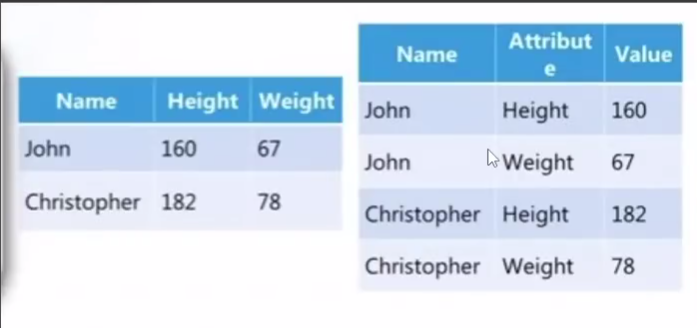

In [166]:
## melt  --> simple example branch
## wide to long
pd.DataFrame({'cse':[120]}).melt()

,variable,value
0,cse,120


In [168]:
pd.DataFrame({'cse':[120],'ece':[100],'mech':[50]})

,cse,ece,mech
0,120,100,50


In [170]:
pd.DataFrame({'cse':[120],'ece':[100],'mech':[50]}).melt()

,variable,value
0,cse,120
1,ece,100
2,mech,50


In [172]:
pd.DataFrame({'cse':[120],'ece':[100],'mech':[50]}).melt(var_name='branch',value_name='num_student')

,branch,num_student
0,cse,120
1,ece,100
2,mech,50


In [178]:
df = pd.DataFrame(
    {
        'branch':['cse','ece','mech'],
        '2020':[130,100,60],
        '2021':[150,120,70],
        '2022':[180,140,90]
    }
)
df

,branch,2020,2021,2022
0,cse,130,150,180
1,ece,100,120,140
2,mech,60,70,90


In [180]:
df.melt()  ## not the correct format

,variable,value
0,branch,cse
1,branch,ece
2,branch,mech
3,2020,130
4,2020,100
5,2020,60
6,2021,150
7,2021,120
8,2021,70
9,2022,180


In [182]:
df.melt(id_vars=['branch'],var_name='year',value_name='num_studnts')

,branch,year,num_studnts
0,cse,2020,130
1,ece,2020,100
2,mech,2020,60
3,cse,2021,150
4,ece,2021,120
5,mech,2021,70
6,cse,2022,180
7,ece,2022,140
8,mech,2022,90


In [216]:
## melt real world example
death = pd.read_csv('time_series_covid19_deaths_global.csv')
confirm = pd.read_csv('time_series_covid19_confirmed_global.csv')

In [218]:
death.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930


In [220]:
death = death.melt(id_vars=['Province/State','Country/Region','Lat','Long'],var_name='date',value_name='num_cases')

In [222]:
confirm = confirm.melt(id_vars=['Province/State','Country/Region','Lat','Long'],var_name='date',value_name='num_death')

In [224]:
death.head()

,Province/State,Country/Region,Lat,Long,date,num_cases
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0
1,NaN,Albania,41.15330,20.168300,1/22/20,0
2,NaN,Algeria,28.03390,1.659600,1/22/20,0
3,NaN,Andorra,42.50630,1.521800,1/22/20,0
4,NaN,Angola,-11.20270,17.873900,1/22/20,0


In [226]:
confirm.head()

,Province/State,Country/Region,Lat,Long,date,num_death
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0
1,NaN,Albania,41.15330,20.168300,1/22/20,0
2,NaN,Algeria,28.03390,1.659600,1/22/20,0
3,NaN,Andorra,42.50630,1.521800,1/22/20,0
4,NaN,Angola,-11.20270,17.873900,1/22/20,0


In [230]:
confirm.merge(death,on=['Province/State','Country/Region','Lat','Long','date'])[['Country/Region','date','num_cases','num_death']]

,Country/Region,date,num_cases,num_death
0,Afghanistan,1/22/20,0,0
1,Albania,1/22/20,0,0
2,Algeria,1/22/20,0,0
3,Andorra,1/22/20,0,0
4,Angola,1/22/20,0,0
...,...,...,...,...
311248,West Bank and Gaza,1/2/23,5708,703228
311249,Winter Olympics 2022,1/2/23,0,535
311250,Yemen,1/2/23,2159,11945
311251,Zambia,1/2/23,4024,334661
